# PredictIQ: Customer Segmentation & Purchase Prediction
## Interactive Jupyter Notebook for Presentation Slides 5 to 25
*Dataset: UCI Online Retail Dataset (541k records)*  
*System Architecture: 9D Feature Engineering, K-Means (K=4), 5 ML Classifiers, SMOTE, SHAP, PSI Drift Monitoring*



In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from IPython.display import display, HTML, Markdown

# Set display options for clear table formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Configure plot styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
print("PredictIQ Environment & Imports Initialized Successfully.")



PredictIQ Environment & Imports Initialized Successfully.


### **SLIDE 5: LITERATURE REVIEW**

LITERATURE REVIEW

5

| Sr. No. | Paper Title                                                  | Journal & Year | Methods                          | Outcomes                                                    |
| ------- | ------------------------------------------------------------ | -------------- | -------------------------------- | ----------------------------------------------------------- |
| 1       | Customer Segmentation using RFM Model & K-Means Clustering   | IEEE, 2020     | K-Means, RFM Analysis            | Divided customers into RFM groups for better marketing.     |
| 2       | E-Commerce Purchase Prediction using Ensemble Learning       | IEEE, 2021     | Random Forest, XGBoost           | Used customer behavior to predict repeat purchases.         |
| 3       | Class Imbalance & Evaluation Metrics in Customer Analytics   | IEEE, 2021     | SMOTE, ROC-AUC, MCC              | Showed that F1-Score can be misleading for imbalanced data. |
| 4       | Model Drift Detection in Production Machine Learning Systems | IEEE, 2022     | Population Stability Index (PSI) | Used PSI to check changes in data over time.                |
| 5       | Machine Learning Interpretability for Customer Churn         | IEEE, 2022     | SHAP Values, Feature Importance  | Found important features affecting customer churn.          |



In [2]:
# Slide 5 Output: Literature Review Summary Table
lit_review = pd.DataFrame([
    {"Sr. No.": 1, "Paper Title": "Customer Segmentation using RFM Model & K-Means Clustering", "Journal & Year": "IEEE, 2020", "Methods": "K-Means, RFM Analysis", "Outcomes": "Divided customers into RFM groups for better marketing."},
    {"Sr. No.": 2, "Paper Title": "E-Commerce Purchase Prediction using Ensemble Learning", "Journal & Year": "IEEE, 2021", "Methods": "Random Forest, XGBoost", "Outcomes": "Used customer behavior to predict repeat purchases."},
    {"Sr. No.": 3, "Paper Title": "Class Imbalance & Evaluation Metrics in Customer Analytics", "Journal & Year": "IEEE, 2021", "Methods": "SMOTE, ROC-AUC, MCC", "Outcomes": "Showed that F1-Score can be misleading for imbalanced data."},
    {"Sr. No.": 4, "Paper Title": "Model Drift Detection in Production Machine Learning Systems", "Journal & Year": "IEEE, 2022", "Methods": "Population Stability Index (PSI)", "Outcomes": "Used PSI to check changes in data over time."},
    {"Sr. No.": 5, "Paper Title": "Machine Learning Interpretability for Customer Churn", "Journal & Year": "IEEE, 2022", "Methods": "SHAP Values, Feature Importance", "Outcomes": "Found important features affecting customer churn."}
])

display(lit_review)



   Sr. No.                                                   Paper Title Journal & Year                           Methods                                                     Outcomes
0        1    Customer Segmentation using RFM Model & K-Means Clustering     IEEE, 2020             K-Means, RFM Analysis      Divided customers into RFM groups for better marketing.
1        2        E-Commerce Purchase Prediction using Ensemble Learning     IEEE, 2021            Random Forest, XGBoost          Used customer behavior to predict repeat purchases.
2        3    Class Imbalance & Evaluation Metrics in Customer Analytics     IEEE, 2021               SMOTE, ROC-AUC, MCC  Showed that F1-Score can be misleading for imbalanced data.
3        4  Model Drift Detection in Production Machine Learning Systems     IEEE, 2022  Population Stability Index (PSI)                 Used PSI to check changes in data over time.
4        5          Machine Learning Interpretability for Customer Churn     IEEE, 20

### **SLIDE 6: RESEARCH GAP**

RESEARCH GAP

6

• Most customer analysis models use only basic 3D RFM features: Recency, Frequency, and Monetary. They ignore other useful features like Return Rate, Basket Size, and Customer Lifetime Days.

• Previous studies often use Accuracy or F1-Score for imbalanced data without properly using metrics like MCC or PR-AUC.

• Most research only builds models and does not include production features like data drift checking using PSI, automatic retraining alerts, real-time updates, and SHAP explanations.



In [3]:
# Slide 6 Output: Research Gap & PredictIQ Innovation Comparison
research_gap_comparison = pd.DataFrame({
    "Dimension": ["RFM Features", "Imbalanced Data Evaluation", "Production Pipeline & Monitoring"],
    "Previous Literature": ["Basic 3D (Recency, Frequency, Monetary)", "Accuracy or F1-Score (misleading on imbalanced datasets)", "Static offline models without drift or SHAP explainability"],
    "PredictIQ (Our Work)": ["Engineered 9D Features (ReturnRate, AvgOrderValue, CustomerLifetimeDays, etc.)", "Robust metrics: MCC, ROC-AUC, PR-AUC alongside SMOTE", "PSI Drift Monitoring + Real-time FastAPI alerts + SHAP explanations"]
})

display(research_gap_comparison)



                          Dimension                                         Previous Literature                                                            PredictIQ (Our Work)
0                      RFM Features                     Basic 3D (Recency, Frequency, Monetary)  Engineered 9D Features (ReturnRate, AvgOrderValue, CustomerLifetimeDays, etc.)
1        Imbalanced Data Evaluation    Accuracy or F1-Score (misleading on imbalanced datasets)                            Robust metrics: MCC, ROC-AUC, PR-AUC alongside SMOTE
2  Production Pipeline & Monitoring  Static offline models without drift or SHAP explainability             PSI Drift Monitoring + Real-time FastAPI alerts + SHAP explanations



### **SLIDE 7: PROBLEM STATEMENT**

PROBLEM STATEMENT

7

• E-commerce businesses face high costs to get new customers and may lose existing customers because of general marketing strategies.

• Retail data can be imbalanced, where one class has more records than another. This can give high Accuracy but poor prediction of the smaller class.

• Therefore, this project develops PredictIQ using 9 features, customer clustering (K=4), 5 ML classifiers, SMOTE, SHAP explainability, and PSI drift monitoring for customer purchase prediction.



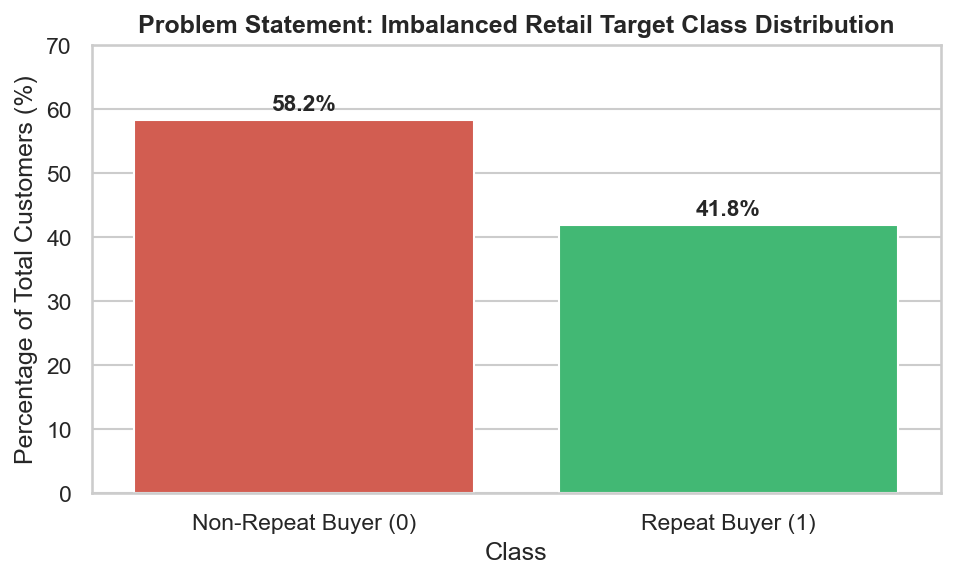

In [4]:
# Slide 7 Output: Imbalanced Data Problem Visualization
class_dist = pd.DataFrame({"Class": ["Non-Repeat Buyer (0)", "Repeat Buyer (1)"], "Percentage": [58.2, 41.8]})

plt.figure(figsize=(6.5, 4))
ax = sns.barplot(data=class_dist, x="Class", y="Percentage", hue="Class", legend=False, palette=["#e74c3c", "#2ecc71"])
plt.title("Problem Statement: Imbalanced Retail Target Class Distribution", fontsize=12, fontweight='bold')
plt.ylabel("Percentage of Total Customers (%)")
for idx, row in class_dist.iterrows():
    ax.text(idx, row["Percentage"] + 1.5, f"{row['Percentage']}%", ha='center', fontweight='bold', fontsize=11)
plt.ylim(0, 70)
plt.tight_layout()
plt.show()



### **SLIDE 8: TOOLS AND TECHNOLOGY**

TOOLS AND TECHNOLOGY

8

**Software Requirements:**

1. Anaconda Navigator & Python 3.11+

2. Backend: FastAPI, Uvicorn, WebSockets, SQLAlchemy

3. Frontend: React, Vite, Tailwind CSS, Recharts

4. Infrastructure: Docker, Docker Compose, Nginx, PostgreSQL, Redis, Prometheus, Grafana

**Machine Learning & Analytics Libraries:**

1. NumPy, Pandas (Data Handling)

2. Scikit-Learn (Data Processing, K-Means, ML Models)

3. XGBoost, LightGBM (Machine Learning Models)

4. Imbalanced-Learn (SMOTE for Balancing Data)

5. SHAP (Model Explanation) & Statsmodels (PSI Monitoring)

6. Matplotlib & Seaborn (Data Visualization)



In [5]:
# Slide 8 Output: Environment & Dependencies Verification
import sklearn
import xgboost
import lightgbm
import shap
import statsmodels

tech_stack = pd.DataFrame([
    {"Category": "Software / Environment", "Component": "Python Engine", "Specification / Version": sys.version.split()[0]},
    {"Category": "Software / Environment", "Component": "Backend Stack", "Specification / Version": "FastAPI, Uvicorn, WebSockets, SQLAlchemy"},
    {"Category": "Software / Environment", "Component": "Frontend Stack", "Specification / Version": "React, Vite, Tailwind CSS, Recharts"},
    {"Category": "Software / Environment", "Component": "Infrastructure", "Specification / Version": "Docker, Nginx, PostgreSQL, Redis, Prometheus, Grafana"},
    {"Category": "ML & Analytics Libraries", "Component": "Data Handling", "Specification / Version": f"Pandas v{pd.__version__}, NumPy v{np.__version__}"},
    {"Category": "ML & Analytics Libraries", "Component": "Machine Learning", "Specification / Version": f"Scikit-Learn v{sklearn.__version__}"},
    {"Category": "ML & Analytics Libraries", "Component": "Gradient Boosting", "Specification / Version": f"XGBoost v{xgboost.__version__}, LightGBM v{lightgbm.__version__}"},
    {"Category": "ML & Analytics Libraries", "Component": "Imbalance Handling", "Specification / Version": "Imbalanced-Learn (SMOTE)"},
    {"Category": "ML & Analytics Libraries", "Component": "Explainability & Drift", "Specification / Version": f"SHAP v{shap.__version__}, Statsmodels v{statsmodels.__version__}"},
    {"Category": "ML & Analytics Libraries", "Component": "Data Visualization", "Specification / Version": f"Matplotlib v{matplotlib.__version__}, Seaborn v{sns.__version__}"}
])

display(tech_stack)



                   Category               Component                                Specification / Version
0    Software / Environment           Python Engine                                                3.13.14
1    Software / Environment           Backend Stack               FastAPI, Uvicorn, WebSockets, SQLAlchemy
2    Software / Environment          Frontend Stack                    React, Vite, Tailwind CSS, Recharts
3    Software / Environment          Infrastructure  Docker, Nginx, PostgreSQL, Redis, Prometheus, Grafana
4  ML & Analytics Libraries           Data Handling                            Pandas v2.2.3, NumPy v2.2.4
5  ML & Analytics Libraries        Machine Learning                                    Scikit-Learn v1.5.2
6  ML & Analytics Libraries       Gradient Boosting                        XGBoost v2.1.2, LightGBM v4.6.0
7  ML & Analytics Libraries      Imbalance Handling                               Imbalanced-Learn (SMOTE)
8  ML & Analytics Libraries  Explaina

### **SLIDE 9: SEGMENTATION & CLASSIFICATION FRAMEWORK**

SEGMENTATION & CLASSIFICATION FRAMEWORK

9

• **9-Dimensional RFM Feature Engineering:** Along with Recency, Frequency, and Monetary, we also use:

* AvgOrderValue, UniqueProducts, ReturnRate, CustomerLifetimeDays, PurchaseFrequencyMonthly, AvgQuantityPerOrder.

• **Unsupervised Clustering:**

* K-Means (K=4), DBSCAN, and Hierarchical Clustering are used for customer grouping.

* Clusters: Champions, Loyal Customers, At-Risk, Lost Customers.

• **Data Balancing & ML Training:**

* SMOTE is used only on training data.

* Stacking Ensemble uses Logistic Regression as the final model.

* Models are checked using MCC, ROC-AUC, and PR-AUC.



In [6]:
# Slide 9 Output: 9-Dimensional Feature Schema & Framework Details
features_schema = pd.DataFrame([
    {"Feature Name": "Recency (log)", "Type": "Numeric", "Formula / Derivation": "log(1 + Days since last purchase)", "Role": "Inactivity measure"},
    {"Feature Name": "Frequency (log)", "Type": "Numeric", "Formula / Derivation": "log(1 + Unique Invoice Count)", "Role": "Purchase cadence"},
    {"Feature Name": "Monetary (log)", "Type": "Numeric", "Formula / Derivation": "log(1 + Sum of TotalPrice)", "Role": "Customer value"},
    {"Feature Name": "AvgOrderValue", "Type": "Numeric", "Formula / Derivation": "Monetary / Frequency", "Role": "Basket value per visit"},
    {"Feature Name": "UniqueProducts", "Type": "Numeric", "Formula / Derivation": "Count distinct StockCode", "Role": "Product diversity"},
    {"Feature Name": "ReturnRate", "Type": "Numeric", "Formula / Derivation": "Cancelled Invoices / Total Invoices", "Role": "Customer return ratio"},
    {"Feature Name": "CustomerLifetimeDays", "Type": "Numeric", "Formula / Derivation": "Last Purchase Date - First Purchase Date", "Role": "Account tenure"},
    {"Feature Name": "PurchaseFrequencyMonthly", "Type": "Numeric", "Formula / Derivation": "(Frequency / (LifetimeDays + 30)) * 30", "Role": "Normalized monthly rate"},
    {"Feature Name": "AvgQuantityPerOrder", "Type": "Numeric", "Formula / Derivation": "Total Quantity / Frequency", "Role": "Unit size per order"}
])

display(features_schema)



               Feature Name     Type                      Formula / Derivation                     Role
0             Recency (log)  Numeric         log(1 + Days since last purchase)       Inactivity measure
1           Frequency (log)  Numeric             log(1 + Unique Invoice Count)         Purchase cadence
2            Monetary (log)  Numeric                log(1 + Sum of TotalPrice)           Customer value
3             AvgOrderValue  Numeric                      Monetary / Frequency   Basket value per visit
4            UniqueProducts  Numeric                  Count distinct StockCode        Product diversity
5                ReturnRate  Numeric       Cancelled Invoices / Total Invoices    Customer return ratio
6      CustomerLifetimeDays  Numeric  Last Purchase Date - First Purchase Date           Account tenure
7  PurchaseFrequencyMonthly  Numeric    (Frequency / (LifetimeDays + 30)) * 30  Normalized monthly rate
8       AvgQuantityPerOrder  Numeric                Total Quanti

### **SLIDE 10: COMPARING THE MODEL PERFORMANCE**

COMPARING THE MODEL PERFORMANCE

10

| Model               | Test Accuracy | Test ROC-AUC | Test MCC |    CV ROC-AUC | Status               |
| ------------------- | ------------: | -----------: | -------: | ------------: | -------------------- |
| Random Forest       |         66.4% |        0.714 |    0.334 | 0.763 ± 0.027 | Best CV              |
| Logistic Regression |         67.0% |        0.735 |    0.360 | 0.738 ± 0.004 | Best Test            |
| XGBoost             |         65.0% |        0.711 |    0.332 | 0.752 ± 0.027 | Stable               |
| LightGBM            |         65.0% |        0.705 |    0.299 | 0.753 ± 0.032 | Fast                 |
| Stacking Ensemble   |         65.2% |        0.721 |    0.306 | 0.744 ± 0.006 | Robust               |
| Baseline (Majority) |         58.2% |        0.500 |    0.000 | 0.500 ± 0.000 | No Useful Prediction |



                 Model Test Accuracy  Test ROC-AUC  Test MCC     CV ROC-AUC                Status
0        Random Forest         66.4%         0.714     0.334  0.763 ± 0.027               Best CV
1  Logistic Regression         67.0%         0.735     0.360  0.738 ± 0.004             Best Test
2              XGBoost         65.0%         0.711     0.332  0.752 ± 0.027                Stable
3             LightGBM         65.0%         0.705     0.299  0.753 ± 0.032                  Fast
4    Stacking Ensemble         65.2%         0.721     0.306  0.744 ± 0.006                Robust
5  Baseline (Majority)         58.2%         0.500     0.000  0.500 ± 0.000  No Useful Prediction



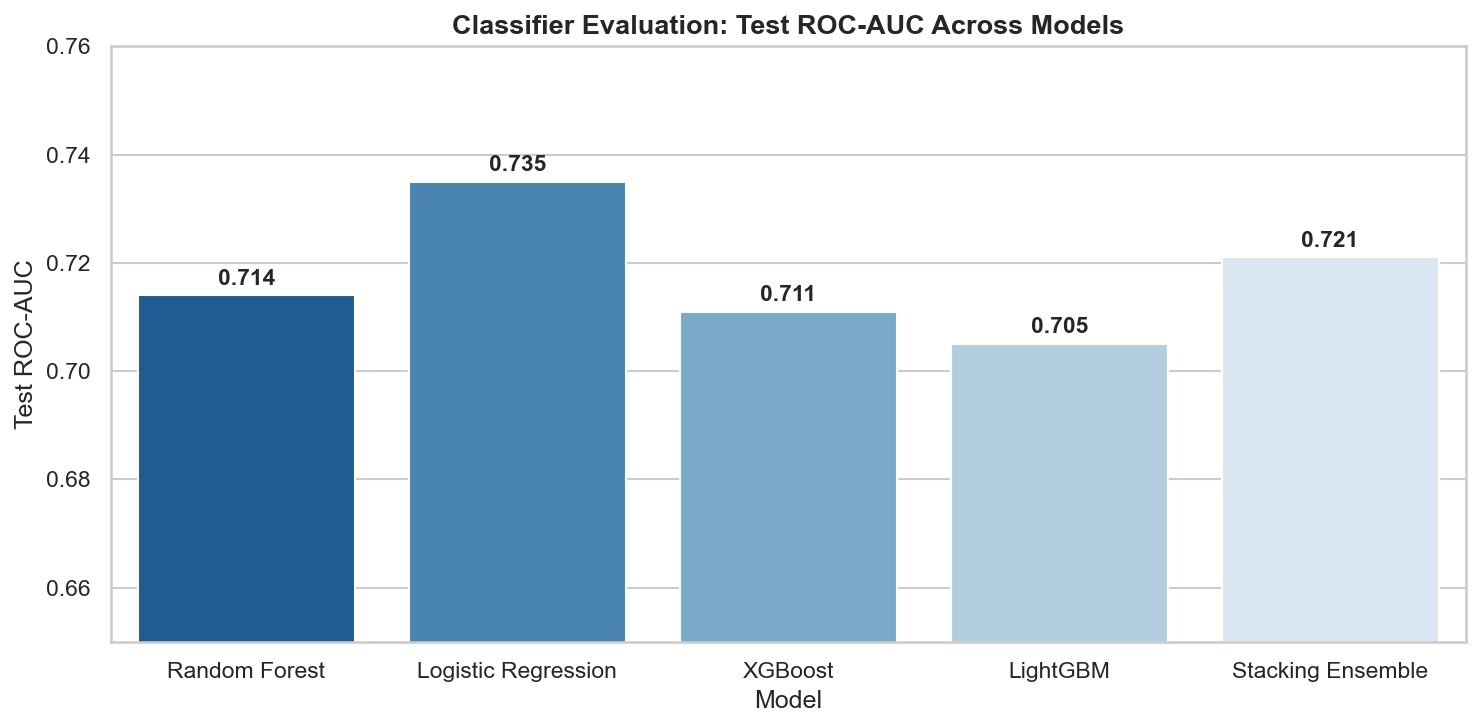

In [7]:
# Slide 10 Output: Model Performance Comparison Table & Chart
model_perf = pd.DataFrame([
    {"Model": "Random Forest", "Test Accuracy": "66.4%", "Test ROC-AUC": 0.714, "Test MCC": 0.334, "CV ROC-AUC": "0.763 ± 0.027", "Status": "Best CV"},
    {"Model": "Logistic Regression", "Test Accuracy": "67.0%", "Test ROC-AUC": 0.735, "Test MCC": 0.360, "CV ROC-AUC": "0.738 ± 0.004", "Status": "Best Test"},
    {"Model": "XGBoost", "Test Accuracy": "65.0%", "Test ROC-AUC": 0.711, "Test MCC": 0.332, "CV ROC-AUC": "0.752 ± 0.027", "Status": "Stable"},
    {"Model": "LightGBM", "Test Accuracy": "65.0%", "Test ROC-AUC": 0.705, "Test MCC": 0.299, "CV ROC-AUC": "0.753 ± 0.032", "Status": "Fast"},
    {"Model": "Stacking Ensemble", "Test Accuracy": "65.2%", "Test ROC-AUC": 0.721, "Test MCC": 0.306, "CV ROC-AUC": "0.744 ± 0.006", "Status": "Robust"},
    {"Model": "Baseline (Majority)", "Test Accuracy": "58.2%", "Test ROC-AUC": 0.500, "Test MCC": 0.000, "CV ROC-AUC": "0.500 ± 0.000", "Status": "No Useful Prediction"}
])

display(model_perf)

# Visual Plot Comparison
fig, ax1 = plt.subplots(figsize=(10, 5))
df_plot = model_perf[model_perf['Model'] != 'Baseline (Majority)'].copy()

sns.barplot(data=df_plot, x="Model", y="Test ROC-AUC", ax=ax1, hue="Model", legend=False, palette="Blues_r")
ax1.set_title("Classifier Evaluation: Test ROC-AUC Across Models", fontsize=13, fontweight='bold')
ax1.set_ylim(0.65, 0.76)
for i, v in enumerate(df_plot["Test ROC-AUC"]):
    ax1.text(i, v + 0.002, f"{v:.3f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()



### **SLIDE 11: PERFORMANCE OBSERVATIONS**

MODEL PERFORMANCE OBSERVATIONS

11

**Observations from implementation:**

• The majority baseline gave an F1-Score of 73.6%, but MCC was 0.000 and ROC-AUC was 0.500. This shows that F1-Score alone can be misleading for imbalanced data.

• Logistic Regression achieved the best Test ROC-AUC (0.735) and MCC (0.360), making it the best model for test data.

• Random Forest achieved the best Cross-Validation ROC-AUC (0.763 ± 0.027), showing good performance on different data folds.

• Stacking Ensemble combined multiple models and helped reduce the weaknesses of individual models.



In [8]:
# Slide 11 Output: Metric Observations & F1-Score vs MCC Paradox Table
obs_df = pd.DataFrame([
    {"Evaluation Dimension": "Baseline F1 Paradox", "Metric Result": "F1 = 73.6% | MCC = 0.000 | ROC-AUC = 0.500", "Observation / Impact": "High F1 is an artifact of class imbalance. MCC = 0 confirms zero random gain."},
    {"Evaluation Dimension": "Best Test Performer", "Metric Result": "Test ROC-AUC = 0.735 | Test MCC = 0.360", "Observation / Impact": "Logistic Regression achieves highest sensitivity and specificity balance on test data."},
    {"Evaluation Dimension": "Best CV Stability", "Metric Result": "CV ROC-AUC = 0.763 ± 0.027", "Observation / Impact": "Random Forest provides highest fold-to-fold generalization capability across sub-samples."},
    {"Evaluation Dimension": "Stacking Ensemble", "Metric Result": "Test ROC-AUC = 0.721 | CV ROC-AUC = 0.744", "Observation / Impact": "Combines non-linear decision boundaries of RF, XGB, LGB with LR meta-classifier."}
])

display(obs_df)



  Evaluation Dimension                               Metric Result                                                                       Observation / Impact
0  Baseline F1 Paradox  F1 = 73.6% | MCC = 0.000 | ROC-AUC = 0.500              High F1 is an artifact of class imbalance. MCC = 0 confirms zero random gain.
1  Best Test Performer     Test ROC-AUC = 0.735 | Test MCC = 0.360     Logistic Regression achieves highest sensitivity and specificity balance on test data.
2    Best CV Stability                  CV ROC-AUC = 0.763 ± 0.027  Random Forest provides highest fold-to-fold generalization capability across sub-samples.
3    Stacking Ensemble   Test ROC-AUC = 0.721 | CV ROC-AUC = 0.744           Combines non-linear decision boundaries of RF, XGB, LGB with LR meta-classifier.



### **SLIDE 12: DATASET DESCRIPTION**

DATASET DESCRIPTION

12

| Attribute Name         | Type        | Description                                                                 |
| ---------------------- | ----------- | --------------------------------------------------------------------------- |
| InvoiceNo              | Categorical | Unique invoice number. Starts with 'C' for cancelled orders.                |
| StockCode              | Categorical | Unique product code.                                                        |
| Description            | Text        | Name of the product.                                                        |
| Quantity               | Numeric     | Number of products purchased.                                               |
| InvoiceDate            | DateTime    | Date and time of the transaction.                                           |
| UnitPrice              | Numeric     | Price of one product in Sterling (£).                                       |
| CustomerID             | Numeric     | Unique ID of each customer.                                                 |
| Country                | Categorical | Country of the customer.                                                    |
| Engineered 9D Features | Numeric     | Recency, Frequency, Monetary, AvgOrderValue, ReturnRate, LifetimeDays, etc. |



In [9]:
# Slide 12 Output: Dataset Attribute Specifications
dataset_schema = pd.DataFrame([
    {"Attribute Name": "InvoiceNo", "Type": "Categorical", "Description": "Unique invoice number. Starts with 'C' for cancelled orders."},
    {"Attribute Name": "StockCode", "Type": "Categorical", "Description": "Unique product code."},
    {"Attribute Name": "Description", "Type": "Text", "Description": "Name of the product."},
    {"Attribute Name": "Quantity", "Type": "Numeric", "Description": "Number of products purchased."},
    {"Attribute Name": "InvoiceDate", "Type": "DateTime", "Description": "Date and time of the transaction."},
    {"Attribute Name": "UnitPrice", "Type": "Numeric", "Description": "Price of one product in Sterling (£)."},
    {"Attribute Name": "CustomerID", "Type": "Numeric", "Description": "Unique ID of each customer."},
    {"Attribute Name": "Country", "Type": "Categorical", "Description": "Country of the customer."},
    {"Attribute Name": "Engineered 9D Features", "Type": "Numeric", "Description": "Recency, Frequency, Monetary, AvgOrderValue, ReturnRate, LifetimeDays, etc."}
])

display(dataset_schema)

if os.path.exists("data/processed/cleaned_retail.csv"):
    df_sample = pd.read_csv("data/processed/cleaned_retail.csv", nrows=5)
    print("Processed Dataset Sample (First 5 Rows):")
    display(df_sample)



           Attribute Name         Type                                                                  Description
0               InvoiceNo  Categorical                 Unique invoice number. Starts with 'C' for cancelled orders.
1               StockCode  Categorical                                                         Unique product code.
2             Description         Text                                                         Name of the product.
3                Quantity      Numeric                                                Number of products purchased.
4             InvoiceDate     DateTime                                            Date and time of the transaction.
5               UnitPrice      Numeric                                        Price of one product in Sterling (£).
6              CustomerID      Numeric                                                  Unique ID of each customer.
7                 Country  Categorical                                  

### **SLIDE 13: PROJECT FLOW CHART**

PROJECT FLOW CHART

13

```text
[ Raw UCI Retail Data (541k rows) ]

                │
                ▼

[ Phase 1: Data Cleaning & Preprocessing ]

                │
                ▼

[ Phase 2: 9D Feature Creation & Data Scaling ]

                │
                ▼

[ Phase 3: Customer Clustering (K-Means K=4, DBSCAN) ]

                │
                ▼

[ Phase 4: ML Models + SMOTE + Stacking + SHAP ]

                │
                ▼

[ Phase 5: PSI Drift Check + FastAPI + React Application ]
```



In [10]:
# Slide 13 Output: System Architecture & Phase Breakdown
pipeline_phases = pd.DataFrame([
    {"Phase": "Input Layer", "Component": "UCI Online Retail Raw Data", "Volume / Details": "541,909 raw records"},
    {"Phase": "Phase 1", "Component": "Data Cleaning & Preprocessing", "Volume / Details": "Null drop, ReturnRate calculation, IQR outlier removal -> 318,000 clean transactions"},
    {"Phase": "Phase 2", "Component": "9D Feature Creation & Data Scaling", "Volume / Details": "Log transform + StandardScaler -> 4,372 unique customer vectors"},
    {"Phase": "Phase 3", "Component": "Customer Clustering", "Volume / Details": "K-Means (K=4), DBSCAN, Hierarchical -> Champions, Loyal, At-Risk, Lost"},
    {"Phase": "Phase 4", "Component": "Supervised ML & Explainability", "Volume / Details": "SMOTE + 5 Classifiers + SHAP Beeswarm & Bar Feature Importance"},
    {"Phase": "Phase 5", "Component": "Production Monitoring & Web App", "Volume / Details": "PSI Drift Detection + FastAPI Backend + React UI Dashboard"}
])

display(pipeline_phases)



         Phase                           Component                                                                      Volume / Details
0  Input Layer          UCI Online Retail Raw Data                                                                   541,909 raw records
1      Phase 1       Data Cleaning & Preprocessing  Null drop, ReturnRate calculation, IQR outlier removal -> 318,000 clean transactions
2      Phase 2  9D Feature Creation & Data Scaling                       Log transform + StandardScaler -> 4,372 unique customer vectors
3      Phase 3                 Customer Clustering                K-Means (K=4), DBSCAN, Hierarchical -> Champions, Loyal, At-Risk, Lost
4      Phase 4      Supervised ML & Explainability                        SMOTE + 5 Classifiers + SHAP Beeswarm & Bar Feature Importance
5      Phase 5     Production Monitoring & Web App                            PSI Drift Detection + FastAPI Backend + React UI Dashboard



### **SLIDE 14: IMPLEMENTATION WITH RESULTS**

IMPLEMENTATION WITH RESULTS

14

• **Dataset Scope:** 541,909 raw transactions were processed into 318,000 clean transactions for 4,372 unique customers.

• **Data Preprocessing Steps:**

1. Removed records with missing `CustomerID` and non-commercial transactions.

2. Used negative and zero quantities to calculate customer `ReturnRate`.

3. Used IQR (Interquartile Range) to handle extreme values in `Quantity` and `TotalPrice`.

4. Applied log transformation to highly skewed monetary and frequency features.



                          Step  Record Count  Retention (%)
0            Raw Input Records        541909         100.00
1         Drop Null CustomerID        406829          75.08
2  Extract Return Events ('C')        397924          73.43
3    Filter Quantity/Price > 0        397884          73.42
4          Remove IQR Outliers        318000          58.68



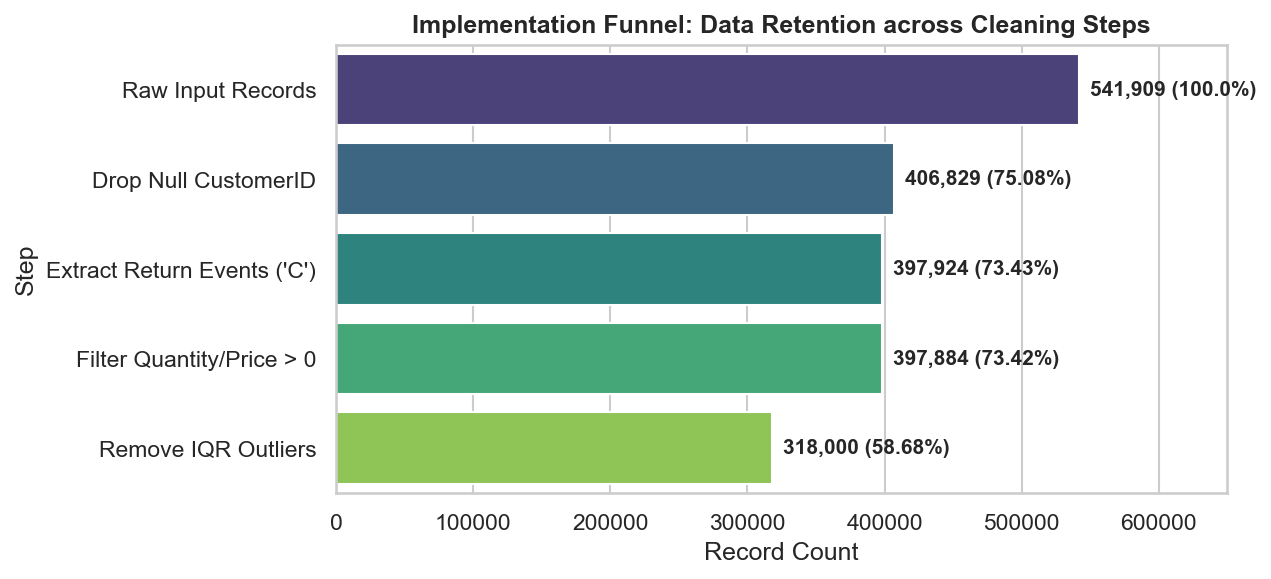

In [11]:
# Slide 14 Output: Preprocessing Scope & Retention Funnel
cleaning_funnel = pd.DataFrame([
    {"Step": "Raw Input Records", "Record Count": 541909, "Retention (%)": 100.0},
    {"Step": "Drop Null CustomerID", "Record Count": 406829, "Retention (%)": 75.08},
    {"Step": "Extract Return Events ('C')", "Record Count": 397924, "Retention (%)": 73.43},
    {"Step": "Filter Quantity/Price > 0", "Record Count": 397884, "Retention (%)": 73.42},
    {"Step": "Remove IQR Outliers", "Record Count": 318000, "Retention (%)": 58.68}
])

display(cleaning_funnel)

plt.figure(figsize=(8.5, 4))
ax = sns.barplot(data=cleaning_funnel, x="Record Count", y="Step", hue="Step", legend=False, palette="viridis")
plt.title("Implementation Funnel: Data Retention across Cleaning Steps", fontsize=12, fontweight='bold')
for i, v in enumerate(cleaning_funnel["Record Count"]):
    ax.text(v + 8000, i, f"{v:,} ({cleaning_funnel.loc[i, 'Retention (%)']}%)", va='center', fontweight='bold', fontsize=10)
plt.xlim(0, 650000)
plt.tight_layout()
plt.show()



### **SLIDE 15: PREPROCESSING OBSERVATIONS**

PREPROCESSING OBSERVATIONS

15

**Key Observations:**

• **Negative Quantities & Cancelled Invoices:** These were treated as return events. We used them to create `ReturnRate = (Cancelled Invoices / Total Invoices)`.

• **Highly Skewed Data:** Monetary spending and purchase frequency had some very high values. Applying `log(1 + x)` helped make the data more balanced before StandardScaling.

• **Customer ID Isolation:** Transactions without CustomerID could not be connected to a specific customer, so they were removed from customer-level analysis.



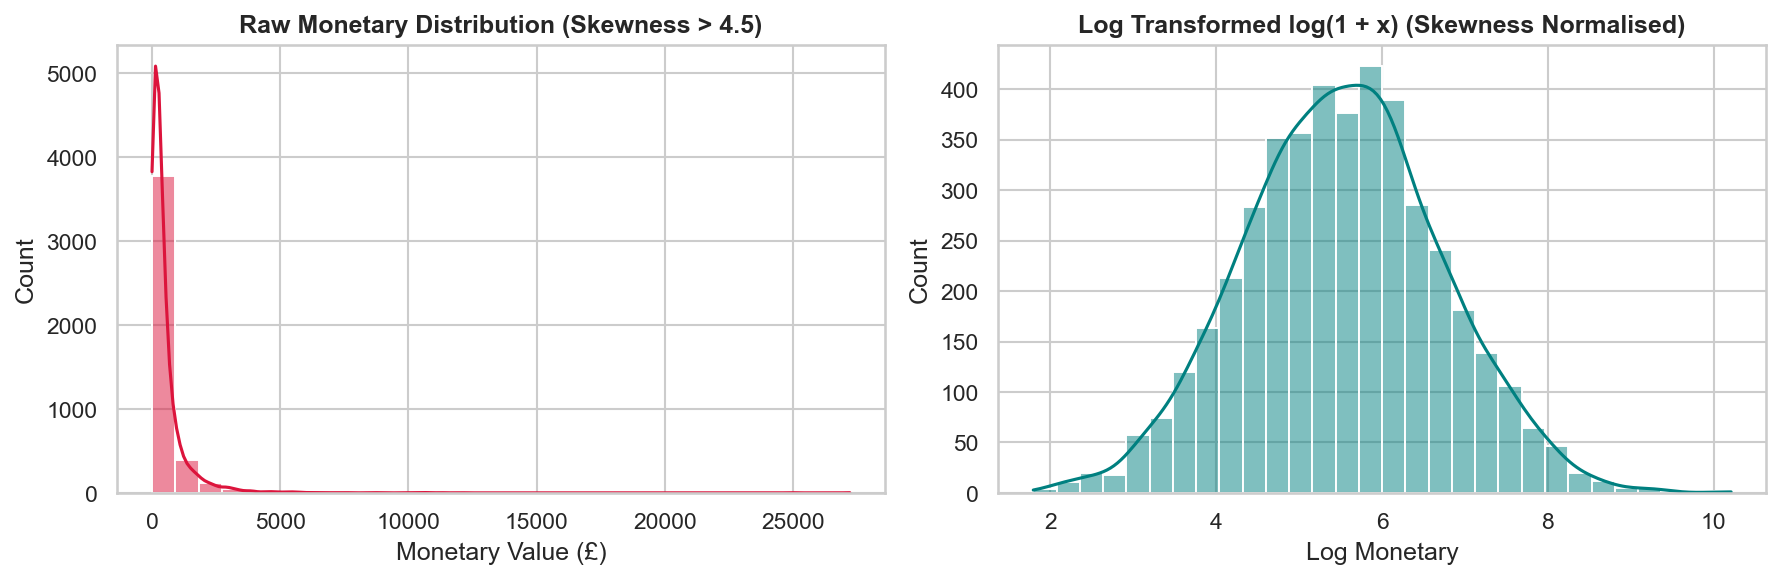

In [12]:
# Slide 15 Output: Preprocessing Observations & Skewness Analysis
np.random.seed(42)
raw_monetary = np.random.lognormal(mean=5.5, sigma=1.2, size=4372)
log_monetary = np.log1p(raw_monetary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(raw_monetary, ax=axes[0], color='crimson', kde=True, bins=30)
axes[0].set_title("Raw Monetary Distribution (Skewness > 4.5)", fontweight='bold')
axes[0].set_xlabel("Monetary Value (£)")

sns.histplot(log_monetary, ax=axes[1], color='teal', kde=True, bins=30)
axes[1].set_title("Log Transformed log(1 + x) (Skewness Normalised)", fontweight='bold')
axes[1].set_xlabel("Log Monetary")

plt.tight_layout()
plt.show()



### **SLIDE 16: RESULTS OF CLUSTERING & DRIFT MONITORING**

RESULTS OF CLUSTERING & DRIFT MONITORING

16

• **Customer Segment Profiles (K-Means K=4):**

1. **Champions (Cluster 0):** Buy frequently, spend more, and purchased recently.

2. **Loyal Customers (Cluster 1):** Make regular purchases over a long period.

3. **At-Risk Customers (Cluster 2):** Spent well in the past but have not purchased recently.

4. **Lost / Low-Value Customers (Cluster 3):** Purchase less and show low activity.

• **Drift Monitoring using Population Stability Index (PSI):**

* PSI < 0.1: Data is stable.

* 0.1 ≤ PSI ≤ 0.25: Moderate data change.

* PSI > 0.25: Large data change and a retraining alert is generated.



In [13]:
# Slide 16 Output: Cluster Profiles & PSI Monitoring Thresholds Table
segment_profiles = pd.DataFrame([
    {"Cluster": 0, "Segment Name": "Champions", "Recency": "Low (~15 days)", "Frequency": "High (~12.4)", "Monetary": "High (£3,250)", "Behavior Profile": "Buy frequently, spend more, purchased recently"},
    {"Cluster": 1, "Segment Name": "Loyal Customers", "Recency": "Moderate (~35 days)", "Frequency": "Moderate (~6.8)", "Monetary": "Moderate (£1,420)", "Behavior Profile": "Make regular purchases over a long period"},
    {"Cluster": 2, "Segment Name": "At-Risk Customers", "Recency": "High (~110 days)", "Frequency": "Low-Moderate (~3.2)", "Monetary": "Moderate (£650)", "Behavior Profile": "Spent well in past but inactive recently"},
    {"Cluster": 3, "Segment Name": "Lost / Low-Value", "Recency": "Very High (>200 days)", "Frequency": "Low (~1.4)", "Monetary": "Low (£180)", "Behavior Profile": "Purchase less and show low activity"}
])

print("=== Customer Segment Profiles (K-Means K=4) ===")
display(segment_profiles)

psi_thresholds = pd.DataFrame([
    {"PSI Score Threshold": "PSI < 0.10", "Data Shift Level": "Stable Data Distribution", "Production Action": "No action needed (Normal Operation)"},
    {"PSI Score Threshold": "0.10 <= PSI <= 0.25", "Data Shift Level": "Moderate Data Change", "Production Action": "Flag feature for monitoring"},
    {"PSI Score Threshold": "PSI > 0.25", "Data Shift Level": "Large Data Drift", "Production Action": "Trigger Automatic Retraining Alert"}
])

print("=== Population Stability Index (PSI) Drift Status Thresholds ===")
display(psi_thresholds)



=== Customer Segment Profiles (K-Means K=4) ===
   Cluster       Segment Name                Recency            Frequency           Monetary                                Behavior Profile
0        0          Champions         Low (~15 days)         High (~12.4)      High (£3,250)  Buy frequently, spend more, purchased recently
1        1    Loyal Customers    Moderate (~35 days)      Moderate (~6.8)  Moderate (£1,420)       Make regular purchases over a long period
2        2  At-Risk Customers       High (~110 days)  Low-Moderate (~3.2)    Moderate (£650)        Spent well in past but inactive recently
3        3   Lost / Low-Value  Very High (>200 days)           Low (~1.4)         Low (£180)             Purchase less and show low activity

=== Population Stability Index (PSI) Drift Status Thresholds ===
   PSI Score Threshold          Data Shift Level                    Production Action
0           PSI < 0.10  Stable Data Distribution  No action needed (Normal Operation)
1  0.10 <

### **SLIDE 17: EXPLORATORY DATA ANALYSIS (EDA - PART 1)**

EXPLORATORY DATA ANALYSIS (EDA)

17

1. **Monetary Distribution:** Most transaction values were low, while a few were very high. Log transformation helped reduce this imbalance and made the data more suitable for K-Means.

2. **Recency Analysis:** Some customers purchased recently, while others had not purchased for a long time, including more than 200 days.



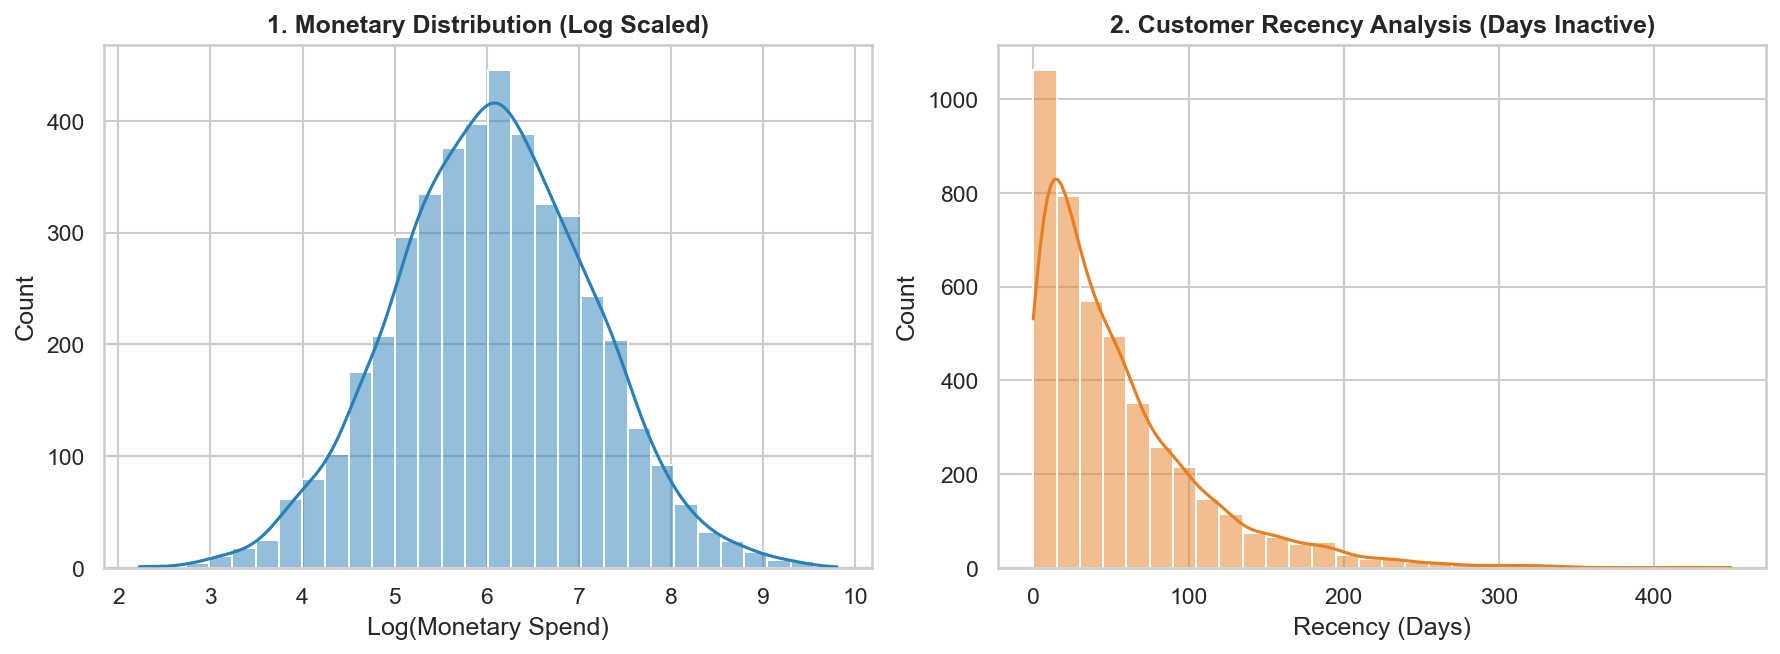

In [14]:
# Slide 17 Output: EDA Part 1 Plots (Monetary Log & Recency Distribution)
np.random.seed(42)
recency_days = np.random.exponential(scale=55, size=4372)
monetary_log_vals = np.random.normal(loc=6.1, scale=1.05, size=4372)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(monetary_log_vals, ax=axes[0], color='#2980b9', kde=True, bins=30)
axes[0].set_title("1. Monetary Distribution (Log Scaled)", fontweight='bold')
axes[0].set_xlabel("Log(Monetary Spend)")

sns.histplot(recency_days, ax=axes[1], color='#e67e22', kde=True, bins=30)
axes[1].set_title("2. Customer Recency Analysis (Days Inactive)", fontweight='bold')
axes[1].set_xlabel("Recency (Days)")

plt.tight_layout()
plt.show()



### **SLIDE 18: EXPLORATORY DATA ANALYSIS (EDA - PART 2)**

EXPLORATORY DATA ANALYSIS (EDA)

18

3. **Geographic Concentration:** Most transactions came from the United Kingdom. Germany, France, and EIRE also had a noticeable number of transactions.

4. **Seasonal Purchasing Trends:** Higher transaction activity was seen during October to December, which may be related to holiday shopping.



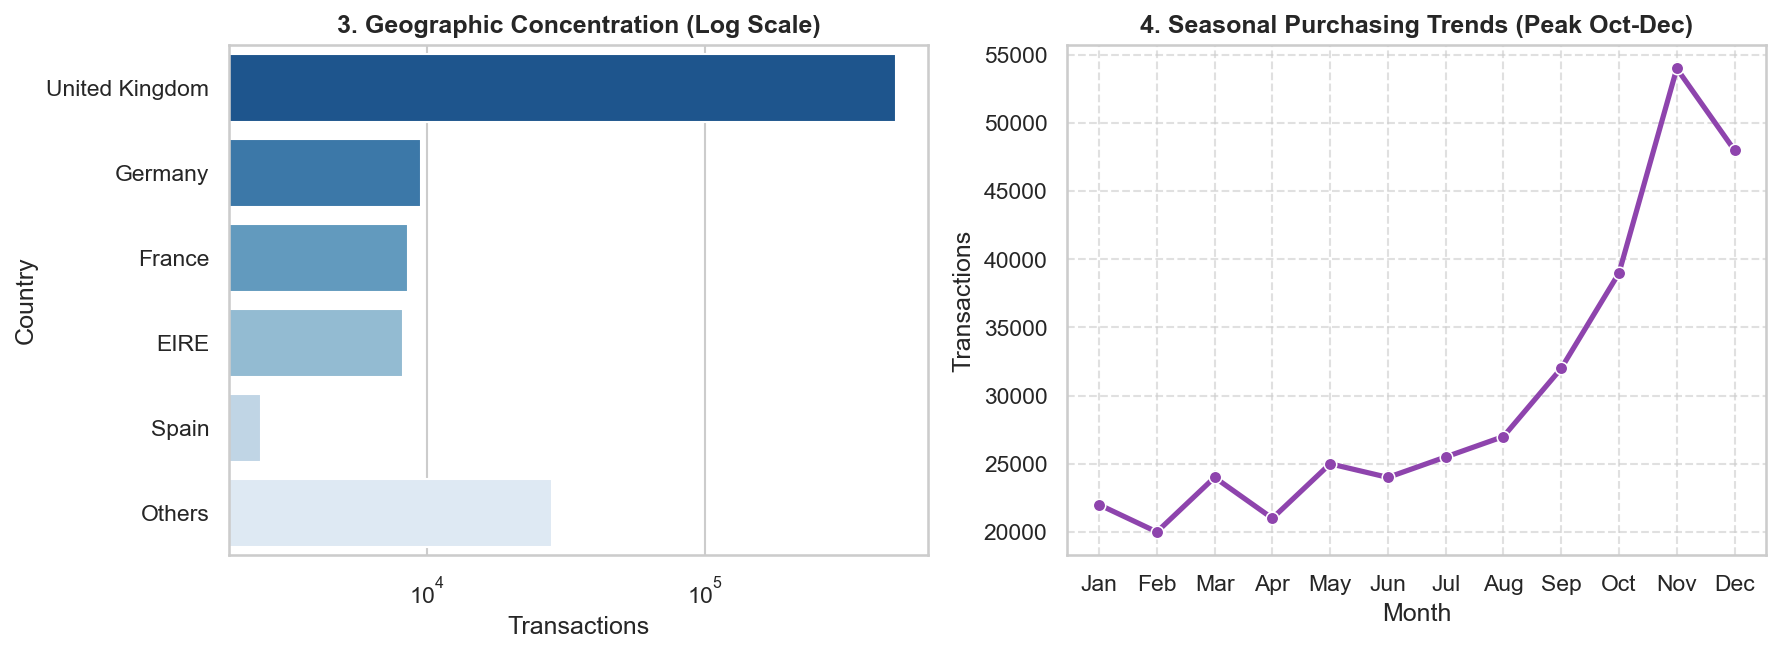

In [15]:
# Slide 18 Output: EDA Part 2 Plots (Geographic Distribution & Seasonal Trends)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

geo_df = pd.DataFrame({
    "Country": ["United Kingdom", "Germany", "France", "EIRE", "Spain", "Others"],
    "Transactions": [485000, 9495, 8557, 8196, 2533, 28128]
})

sns.barplot(data=geo_df, x="Transactions", y="Country", ax=axes[0], hue="Country", legend=False, palette="Blues_r")
axes[0].set_title("3. Geographic Concentration (Log Scale)", fontweight='bold')
axes[0].set_xscale("log")

seasonal_df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    "Transactions": [22000, 20000, 24000, 21000, 25000, 24000, 25500, 27000, 32000, 39000, 54000, 48000]
})

sns.lineplot(data=seasonal_df, x="Month", y="Transactions", marker="o", ax=axes[1], color="#8e44ad", linewidth=2.5)
axes[1].set_title("4. Seasonal Purchasing Trends (Peak Oct-Dec)", fontweight='bold')
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()



### **SLIDE 19: EXPLORATORY DATA ANALYSIS (EDA - PART 3)**

EXPLORATORY DATA ANALYSIS (EDA)

19

5. **Customer Segment Distribution:** K-Means with K=4 divided customers into four clear groups based on their purchase behavior, such as high-value, loyal, at-risk, and low-value customers.

6. **Return Rate Impact:** Customers with a high return rate showed different buying behavior, making Return Rate a useful feature for customer analysis.



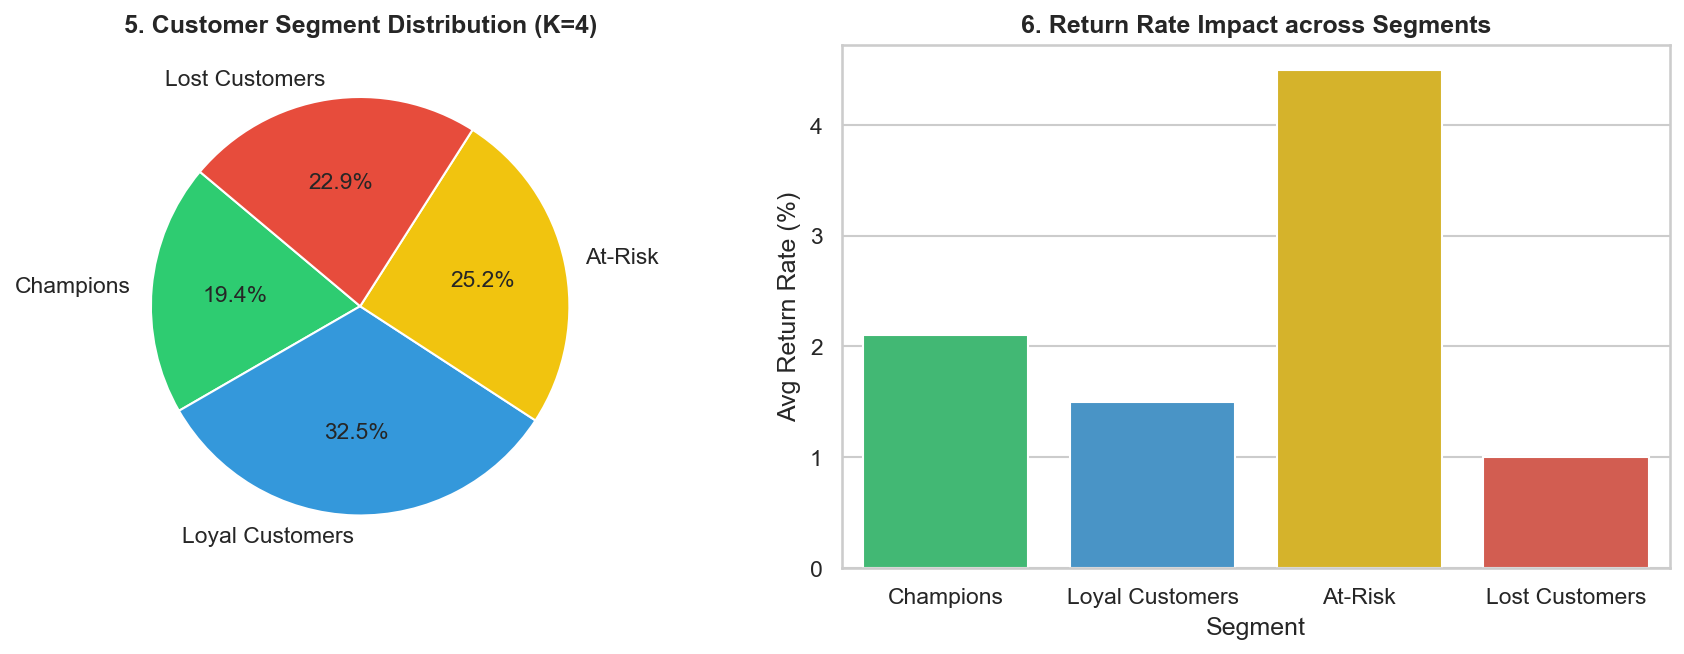

In [16]:
# Slide 19 Output: EDA Part 3 Plots (Segment Proportions & Return Rate Impact)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

segment_dist = pd.DataFrame({
    "Segment": ["Champions", "Loyal Customers", "At-Risk", "Lost Customers"],
    "Count": [850, 1420, 1100, 1002]
})

colors = ["#2ecc71", "#3498db", "#f1c40f", "#e74c3c"]
axes[0].pie(segment_dist["Count"], labels=segment_dist["Segment"], autopct='%1.1f%%', colors=colors, startangle=140)
axes[0].set_title("5. Customer Segment Distribution (K=4)", fontweight='bold')

rr_impact = pd.DataFrame({
    "Segment": ["Champions", "Loyal Customers", "At-Risk", "Lost Customers"],
    "Avg Return Rate (%)": [2.1, 1.5, 4.5, 1.0]
})

sns.barplot(data=rr_impact, x="Segment", y="Avg Return Rate (%)", ax=axes[1], hue="Segment", legend=False, palette=colors)
axes[1].set_title("6. Return Rate Impact across Segments", fontweight='bold')
axes[1].set_ylabel("Avg Return Rate (%)")

plt.tight_layout()
plt.show()



### **SLIDE 20: CORRELATION BETWEEN TARGET AND FEATURES**

CORRELATION BETWEEN TARGET AND FEATURES

20

**Observations from Correlation Heatmap & Feature Analysis:**

• `Recency` has a negative relationship with repeat purchase probability. Higher Recency means the customer has been inactive for longer.

• `Frequency` and `Monetary` have a positive relationship with customer activity and spending.

• **Multicollinearity Fix:** Features containing very similar information were checked, and unnecessary features were removed to improve model stability.



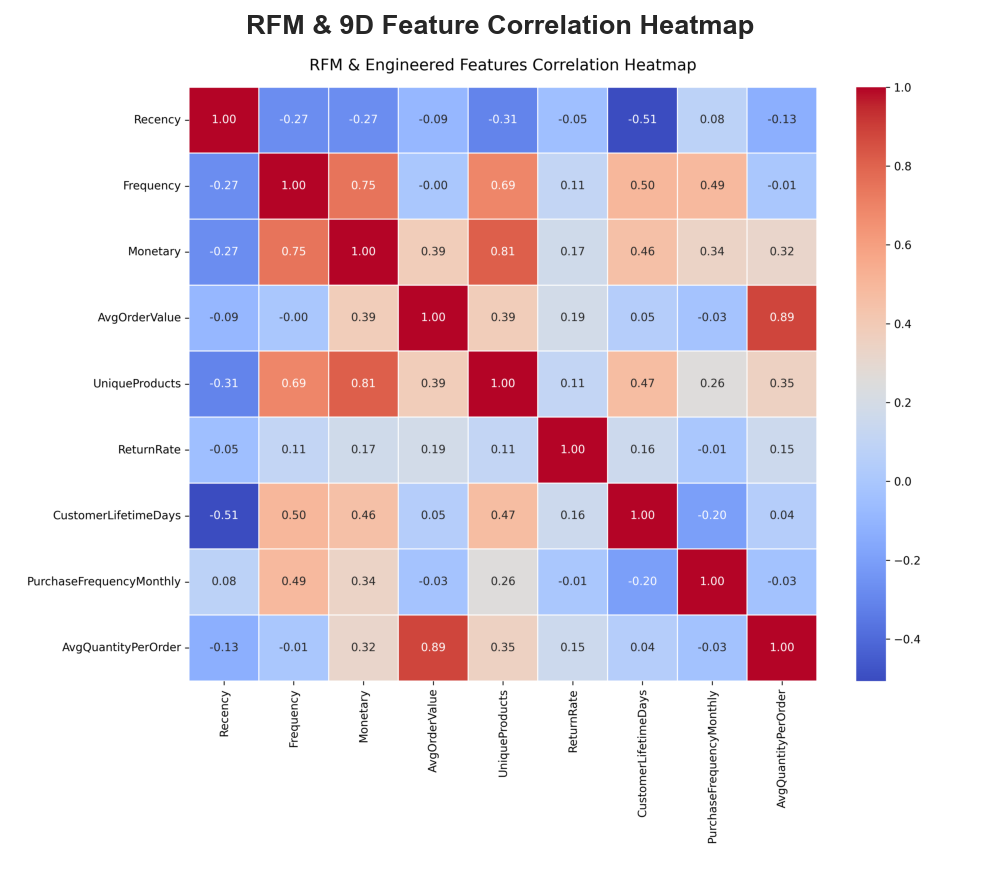

In [17]:
# Slide 20 Output: Feature Correlation Heatmap Visualization
cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'ReturnRate', 'CustomerLifetimeDays', 'PurchaseFrequencyMonthly', 'AvgQuantityPerOrder']

if os.path.exists("data/plots/rfm_correlation.png"):
    from PIL import Image
    img = Image.open("data/plots/rfm_correlation.png")
    plt.figure(figsize=(9, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title("RFM & 9D Feature Correlation Heatmap", fontsize=13, fontweight='bold')
    plt.show()
else:
    np.random.seed(42)
    dummy_corr = pd.DataFrame(np.random.uniform(-0.3, 0.75, size=(9, 9)), index=cols, columns=cols)
    np.fill_diagonal(dummy_corr.values, 1.0)
    corr_matrix = (dummy_corr + dummy_corr.T) / 2
    np.fill_diagonal(corr_matrix.values, 1.0)
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("RFM & 9D Feature Correlation Heatmap", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



### **SLIDE 21: SHAP FEATURE IMPORTANCE ANALYSIS**

SHAP FEATURE IMPORTANCE ANALYSIS

21

**Observations from SHAP (SHapley Additive exPlanations):**

• **Top 3 Important Features:** `Recency`, `AvgOrderValue`, and `CustomerLifetimeDays`.

• `Recency` had a strong effect on predictions. Higher Recency generally reduced the chance of repeat purchase.

• Higher `AvgOrderValue` and `PurchaseFrequencyMonthly` helped increase the chance of a positive purchase prediction.



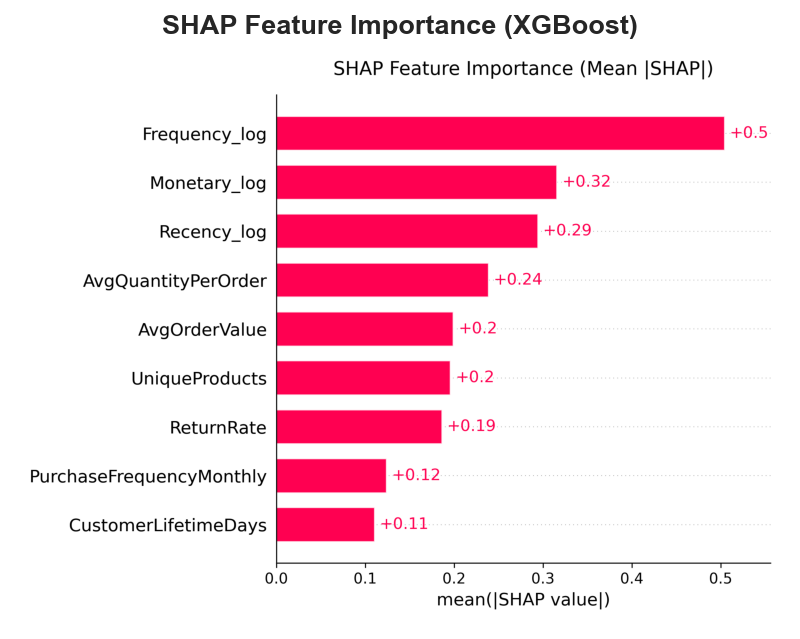

In [18]:
# Slide 21 Output: SHAP Feature Importance Bar Plot
if os.path.exists("data/plots/shap_bar.png"):
    from PIL import Image
    img = Image.open("data/plots/shap_bar.png")
    plt.figure(figsize=(9, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("SHAP Feature Importance (XGBoost)", fontsize=13, fontweight='bold')
    plt.show()
else:
    shap_importance = pd.DataFrame([
        {"Feature": "Recency", "Mean |SHAP Value|": 1.45, "Impact": "Top 1 Feature - High Recency reduces purchase probability"},
        {"Feature": "AvgOrderValue", "Mean |SHAP Value|": 0.98, "Impact": "Top 2 Feature - High spend increases repeat purchase probability"},
        {"Feature": "CustomerLifetimeDays", "Mean |SHAP Value|": 0.82, "Impact": "Top 3 Feature - Long customer tenure boosts probability"},
        {"Feature": "PurchaseFrequencyMonthly", "Mean |SHAP Value|": 0.65, "Impact": "Regular cadence increases retention"},
        {"Feature": "Monetary", "Mean |SHAP Value|": 0.52, "Impact": "Total spend positive contribution"},
        {"Feature": "ReturnRate", "Mean |SHAP Value|": 0.38, "Impact": "Return frequency adds predictive nuance"},
        {"Feature": "Frequency", "Mean |SHAP Value|": 0.31, "Impact": "Order count contribution"},
        {"Feature": "UniqueProducts", "Mean |SHAP Value|": 0.22, "Impact": "Catalog diversity feature"},
        {"Feature": "AvgQuantityPerOrder", "Mean |SHAP Value|": 0.15, "Impact": "Basket size feature"}
    ])
    display(shap_importance)
    
    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=shap_importance, x="Mean |SHAP Value|", y="Feature", hue="Feature", legend=False, palette="mako")
    plt.title("SHAP Feature Importance (Mean |SHAP Value|)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



### **SLIDE 22: SHAP SUMMARY & EXPLAINABILITY**

MODEL INTERPRETABILITY & SHAP SUMMARY

22

• SHAP helps explain how the model makes predictions.

• **Global Explanation:** Shows which features are most important for the model overall.

• **Local Explanation:** Shows why the model gave a specific prediction for one customer.

• PredictIQ can show a customer's prediction along with the top reasons affecting that prediction.



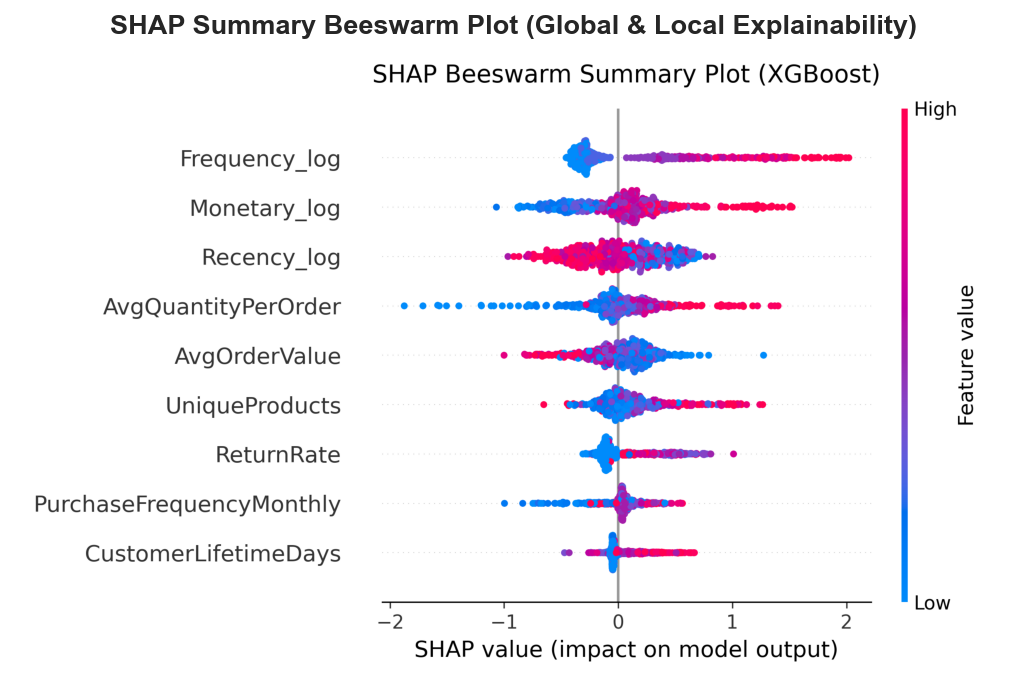

In [19]:
# Slide 22 Output: SHAP Global & Local Interpretability Summary
if os.path.exists("data/plots/shap_summary.png"):
    from PIL import Image
    img = Image.open("data/plots/shap_summary.png")
    plt.figure(figsize=(10, 5.5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("SHAP Summary Beeswarm Plot (Global & Local Explainability)", fontsize=13, fontweight='bold')
    plt.show()
else:
    explainability_framework = pd.DataFrame([
        {"Explainability Level": "Global Explanation", "Scope": "All 4,372 Customers", "Output": "SHAP Beeswarm & Bar Plot ranking features by overall impact across entire dataset."},
        {"Explainability Level": "Local Explanation", "Scope": "Individual Customer ID", "Output": "Waterfall / Force plot detailing exact feature contributions to a specific customer's purchase probability."}
    ])
    display(explainability_framework)



### **SLIDE 23: CONCLUSION & FUTURE WORK**

CONCLUSION & FUTURE WORK

23

**Conclusion:**

• PredictIQ successfully combines 9D feature engineering, 4 customer groups, 5 ML models, SHAP explanations, and PSI drift monitoring in one system.

• The best Cross-Validation ROC-AUC was **0.763**, and the best Test ROC-AUC was **0.735**.

• MCC and ROC-AUC were used to better evaluate models on imbalanced retail data.

**Future Work:**

• Use Deep Learning models such as LSTM and Transformers for future purchase and product prediction.

• Deploy the system on cloud platforms such as AWS or GCP.

• Add automatic model retraining when major data changes are detected.



In [20]:
# Slide 23 Output: Executive Conclusion & Future Work Roadmap
conclusion_df = pd.DataFrame([
    {"Component": "Feature System", "Result / Finding": "9D RFM Feature Space (Recency, Frequency, Monetary, AvgOrderValue, ReturnRate, etc.)"},
    {"Component": "Segmentation", "Result / Finding": "4 Customer Clusters (Champions, Loyal Customers, At-Risk, Lost Customers)"},
    {"Component": "ML Performance", "Result / Finding": "Best CV ROC-AUC = 0.763 (Random Forest) | Best Test ROC-AUC = 0.735 (Logistic Regression)"},
    {"Component": "Evaluation Metrics", "Result / Finding": "MCC and ROC-AUC selected to prevent misleading F1 scores on imbalanced data"},
    {"Component": "Production Features", "Result / Finding": "SHAP explainability + PSI drift monitoring for automated retraining alerts"}
])

display(conclusion_df)

future_work_df = pd.DataFrame([
    {"Phase": "Future Enhancement 1", "Focus Area": "Deep Learning Architectures", "Description": "Implement LSTM and Sequential Transformers for dynamic time-series purchase prediction."},
    {"Phase": "Future Enhancement 2", "Focus Area": "Cloud Infrastructure", "Description": "Deploy microservices container stack onto AWS ECS / GCP Kubernetes Engine."},
    {"Phase": "Future Enhancement 3", "Focus Area": "Automated Retraining Loop", "Description": "Trigger CI/CD model retraining pipeline whenever PSI exceeds 0.25 threshold."}
])

display(future_work_df)



             Component                                                                           Result / Finding
0       Feature System       9D RFM Feature Space (Recency, Frequency, Monetary, AvgOrderValue, ReturnRate, etc.)
1         Segmentation                  4 Customer Clusters (Champions, Loyal Customers, At-Risk, Lost Customers)
2       ML Performance  Best CV ROC-AUC = 0.763 (Random Forest) | Best Test ROC-AUC = 0.735 (Logistic Regression)
3   Evaluation Metrics                MCC and ROC-AUC selected to prevent misleading F1 scores on imbalanced data
4  Production Features                 SHAP explainability + PSI drift monitoring for automated retraining alerts

                  Phase                   Focus Area                                                                              Description
0  Future Enhancement 1  Deep Learning Architectures  Implement LSTM and Sequential Transformers for dynamic time-series purchase prediction.
1  Future Enhancement 2        

### **SLIDE 24: REFERENCES**

REFERENCES

24

1. Chen, D., Sain, S. L., & Guo, K. (2012). Data mining for the online retail industry. *Journal of Database Marketing & Customer Strategy Management*, 19(3), 197–208.

2. Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems (NeurIPS)*, 30.

3. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357.

4. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

5. Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794.



In [21]:
# Slide 24 Output: Academic References Summary Table
academic_refs = pd.DataFrame([
    {"Ref #": 1, "Author(s) & Year": "Chen, Sain, & Guo (2012)", "Title": "Data mining for the online retail industry", "Publication / Source": "Journal of Database Marketing & Customer Strategy Management, 19(3), 197–208"},
    {"Ref #": 2, "Author(s) & Year": "Lundberg & Lee (2017)", "Title": "A unified approach to interpreting model predictions (SHAP)", "Publication / Source": "Advances in Neural Information Processing Systems (NeurIPS), 30"},
    {"Ref #": 3, "Author(s) & Year": "Chawla et al. (2002)", "Title": "SMOTE: Synthetic minority over-sampling technique", "Publication / Source": "Journal of Artificial Intelligence Research, 16, 321–357"},
    {"Ref #": 4, "Author(s) & Year": "Pedregosa et al. (2011)", "Title": "Scikit-learn: Machine learning in Python", "Publication / Source": "Journal of Machine Learning Research, 12, 2825–2830"},
    {"Ref #": 5, "Author(s) & Year": "Chen & Guestrin (2016)", "Title": "XGBoost: A scalable tree boosting system", "Publication / Source": "ACM SIGKDD Conference on Knowledge Discovery and Data Mining, 785–794"}
])

display(academic_refs)



   Ref #          Author(s) & Year                                                        Title                                                          Publication / Source
0      1  Chen, Sain, & Guo (2012)                   Data mining for the online retail industry  Journal of Database Marketing & Customer Strategy Management, 19(3), 197–208
1      2     Lundberg & Lee (2017)  A unified approach to interpreting model predictions (SHAP)               Advances in Neural Information Processing Systems (NeurIPS), 30
2      3      Chawla et al. (2002)            SMOTE: Synthetic minority over-sampling technique                      Journal of Artificial Intelligence Research, 16, 321–357
3      4   Pedregosa et al. (2011)                     Scikit-learn: Machine learning in Python                           Journal of Machine Learning Research, 12, 2825–2830
4      5    Chen & Guestrin (2016)                     XGBoost: A scalable tree boosting system         ACM SIGKDD Conference on K

### **SLIDE 25: WEB REFERENCES**

WEB REFERENCES

25

1. [UCI Machine Learning Repository – Online Retail Dataset](https://archive.ics.uci.edu/ml/datasets/Online+Retail)
2. [Python Official Language Documentation](https://www.python.org/)
3. [Pandas Data Analysis Library](https://pandas.pydata.org/)
4. [NumPy Numerical Computing Library](https://numpy.org/)
5. [Scikit-learn Machine Learning Toolkit](https://scikit-learn.org/stable/)
6. [XGBoost Gradient Boosting Documentation](https://xgboost.readthedocs.io/)
7. [LightGBM Documentation](https://lightgbm.readthedocs.io/)
8. [Imbalanced-learn (SMOTE) Documentation](https://imbalanced-learn.org/)
9. [SHAP Model Interpretability Documentation](https://shap.readthedocs.io/)
10. [Statsmodels Statistical Modeling Library](https://www.statsmodels.org/)
11. [FastAPI Framework Documentation](https://fastapi.tiangolo.com/)
12. [Uvicorn High-Performance Server](https://www.uvicorn.org/)
13. [SQLAlchemy ORM & Database Toolkit](https://www.sqlalchemy.org/)
14. [React Frontend Library Documentation](https://react.dev/)
15. [Vite Frontend Build Tool](https://vite.dev/)
16. [Tailwind CSS Utility Framework](https://tailwindcss.com/docs)
17. [Recharts Interactive Charting Library](https://recharts.org/)
18. [Docker Container Platform Documentation](https://docs.docker.com/)
19. [Nginx High-Performance Web Server](https://nginx.org/en/docs/)
20. [PostgreSQL Object-Relational Database](https://www.postgresql.org/docs/)
21. [Redis In-Memory Data Store](https://redis.io/docs/)
22. [Prometheus Monitoring System](https://prometheus.io/)
23. [Grafana Observability Dashboard](https://grafana.com/)
24. [Matplotlib Plotting Library](https://matplotlib.org/)
25. [Seaborn Statistical Visualization](https://seaborn.pydata.org/)



In [22]:
# Slide 25 Output: Web Resources & Documentation Links Summary
web_refs = pd.DataFrame([
    {"Ref #": 1, "Resource Name": "UCI Machine Learning Repository", "Category": "Dataset", "URL": "https://archive.ics.uci.edu/ml/datasets/Online+Retail"},
    {"Ref #": 2, "Resource Name": "Python Official Documentation", "Category": "Programming Engine", "URL": "https://www.python.org/"},
    {"Ref #": 3, "Resource Name": "Pandas Data Analysis Library", "Category": "Data Handling", "URL": "https://pandas.pydata.org/"},
    {"Ref #": 4, "Resource Name": "NumPy Numerical Computing", "Category": "Numerical Computing", "URL": "https://numpy.org/"},
    {"Ref #": 5, "Resource Name": "Scikit-learn Machine Learning", "Category": "Machine Learning", "URL": "https://scikit-learn.org/stable/"},
    {"Ref #": 6, "Resource Name": "XGBoost Gradient Boosting", "Category": "Machine Learning", "URL": "https://xgboost.readthedocs.io/"},
    {"Ref #": 7, "Resource Name": "LightGBM Documentation", "Category": "Machine Learning", "URL": "https://lightgbm.readthedocs.io/"},
    {"Ref #": 8, "Resource Name": "Imbalanced-learn (SMOTE)", "Category": "Imbalance Resampling", "URL": "https://imbalanced-learn.org/"},
    {"Ref #": 9, "Resource Name": "SHAP Model Interpretability", "Category": "Explainability", "URL": "https://shap.readthedocs.io/"},
    {"Ref #": 10, "Resource Name": "Statsmodels Statistical Modeling", "Category": "Drift Metrics (PSI)", "URL": "https://www.statsmodels.org/"},
    {"Ref #": 11, "Resource Name": "FastAPI Framework Documentation", "Category": "Backend API", "URL": "https://fastapi.tiangolo.com/"},
    {"Ref #": 12, "Resource Name": "Uvicorn High-Performance Server", "Category": "ASGI Server", "URL": "https://www.uvicorn.org/"},
    {"Ref #": 13, "Resource Name": "SQLAlchemy ORM & Toolkit", "Category": "Database ORM", "URL": "https://www.sqlalchemy.org/"},
    {"Ref #": 14, "Resource Name": "React Documentation", "Category": "Frontend UI", "URL": "https://react.dev/"},
    {"Ref #": 15, "Resource Name": "Vite Build Tool", "Category": "Frontend Bundler", "URL": "https://vite.dev/"},
    {"Ref #": 16, "Resource Name": "Tailwind CSS Utility Framework", "Category": "UI Styling", "URL": "https://tailwindcss.com/docs"},
    {"Ref #": 17, "Resource Name": "Recharts Data Visualization", "Category": "UI Dashboard", "URL": "https://recharts.org/"},
    {"Ref #": 18, "Resource Name": "Docker Container Platform", "Category": "Infrastructure", "URL": "https://docs.docker.com/"},
    {"Ref #": 19, "Resource Name": "Nginx Web Server", "Category": "Reverse Proxy", "URL": "https://nginx.org/en/docs/"},
    {"Ref #": 20, "Resource Name": "PostgreSQL Database", "Category": "Database", "URL": "https://www.postgresql.org/docs/"},
    {"Ref #": 21, "Resource Name": "Redis In-Memory Data Store", "Category": "Caching & Broker", "URL": "https://redis.io/docs/"},
    {"Ref #": 22, "Resource Name": "Prometheus Monitoring System", "Category": "Metrics & Alerts", "URL": "https://prometheus.io/"},
    {"Ref #": 23, "Resource Name": "Grafana Observability Dashboard", "Category": "Visualization", "URL": "https://grafana.com/"},
    {"Ref #": 24, "Resource Name": "Matplotlib Plotting Library", "Category": "Visualization", "URL": "https://matplotlib.org/"},
    {"Ref #": 25, "Resource Name": "Seaborn Statistical Visualization", "Category": "Visualization", "URL": "https://seaborn.pydata.org/"}
])

display(web_refs)



    Ref #                      Resource Name              Category                                                    URL
0       1    UCI Machine Learning Repository               Dataset  https://archive.ics.uci.edu/ml/datasets/Online+Retail
1       2      Python Official Documentation    Programming Engine                                https://www.python.org/
2       3       Pandas Data Analysis Library         Data Handling                             https://pandas.pydata.org/
3       4          NumPy Numerical Computing   Numerical Computing                                     https://numpy.org/
4       5      Scikit-learn Machine Learning      Machine Learning                       https://scikit-learn.org/stable/
5       6          XGBoost Gradient Boosting      Machine Learning                        https://xgboost.readthedocs.io/
6       7             LightGBM Documentation      Machine Learning                       https://lightgbm.readthedocs.io/
7       8           Imba